# MIDL quick demo for math problem

Build `D_in` -> compute `basis` -> construct dimensionless `Pi` -> run `MIDL.fit` -> recover exponents.

In [67]:
import numpy as np
import midl
from midl import MIDL


In [129]:
# Synthetic data
def u_xyz(x, y, z, L):
    # Make trig arguments dimensionless
    return np.sin(x / L) * np.cos((y * z) / (L**2))

# Generate synthetic dataset
x_vals = np.linspace(0.01, 2*np.pi + 0.01, 20) 
y_vals = np.linspace(0.01, 2*np.pi + 0.01, 20) 
z_vals = np.linspace(0.01, 2*np.pi + 0.01, 20)
L0 = 1.0

u_array = []
params = []

for x0 in x_vals:
    for y0 in y_vals:
        for z0 in z_vals:
            u_array.append(u_xyz(x0, y0, z0, L0))
            params.append([x0, y0, z0, L0])

u = np.array(u_array).reshape(-1, 1)
params = np.array(params)

X_raw = params
# Dimension matrix D_in (shape: (l, m))
D_in = np.matrix([1, 1, 1, 1])
print("Dimension matrix D_in:\n", D_in)

# Compute basis vectors (π exponents) and rank
basis, r = midl.calc_basis(D_in)
print("Null space dimension:", D_in.shape[1] - r)
print("basis shape:", basis.shape)
print("basis (π exponents):\n", basis)

# Transform X_raw to dimensionless inputs Pi
Pi = np.zeros((X_raw.shape[0], basis.shape[1]))

for i in range(X_raw.shape[0]):
    log_x = np.log(X_raw[i, :])
    Pi[i, :] = np.exp(log_x @ basis)

Dimension matrix D_in:
 [[1 1 1 1]]
Null space dimension: 3
basis shape: (4, 3)
basis (π exponents):
 [[-0.5        -0.5        -0.5       ]
 [ 0.83333333 -0.16666667 -0.16666667]
 [-0.16666667  0.83333333 -0.16666667]
 [-0.16666667 -0.16666667  0.83333333]]


In [130]:
# Run MIDL
model = MIDL(
    k_neighbors=5,
    de_maxiter=200,
    random_state=42,
)

result = model.fit(Pi_independent=Pi, pi_dependent=u,threshold=5)
pi_hat = MIDL.compose_new_pi(Pi, result["W"])

print("\n=== MIDL Results ===")
print("MI scores:", result["mi_scores"])
#print("W (columns are w_i):")
#print(result["W"])
print("dominant_q:", result["dominant_q"])
print("drop ratios I_i / I_(i+1):", result["drop_ratios"])

# Recover exponents in the original variable space
alpha = basis @ result["W"]
print("\n=== Recovered exponents ===")
print(alpha)


[Step 1] MI = 1.661845
[Step 2] MI = 1.084556
   ratio = 1.532
[Step 3] MI = 0.074786
   ratio = 14.502
   >>> Early stopping triggered at step 3

=== MIDL Results ===
MI scores: [1.66184499 1.08455586]
dominant_q: 2
drop ratios I_i / I_(i+1): 14.502148635570066

=== Recovered exponents ===
[[-0.70931837 -0.49685758]
 [ 0.00222042  0.49999139]
 [ 0.00221667  0.49999877]
 [ 0.70488127 -0.50313258]]


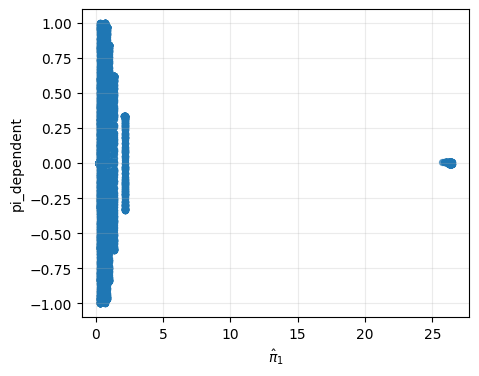

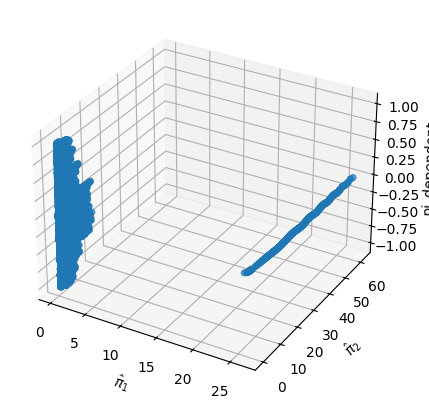

In [131]:
if result["dominant_q"] >= 2:
    ax2d, ax3d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=u,
        W=result["W"],
        dominant_q=result["dominant_q"],
        component_index=0,
    )
else:
    ax2d = MIDL.plot_component_vs_dependent(
        Pi_independent=Pi,
        pi_dependent=u,
        W=result["W"],
        dominant_q=result["dominant_q"],
        component_index=0,
    )